# Öneri Sistemleri

Öneri sistemleri, kullanıcıların geçmiş tercihlerine dayanarak onlara ürünler önermek için kullanılır. Öneri sistemleri genel olarak aşağıdaki kategorilere ayrılır:

- **İçerik tabanlı (Content-based)**: Ürün özelliklerinin (ör. anahtar kelimeler, kategoriler) ve kullanıcı tercihlerinin benzerliğine dayanır.  
  Örneğin, bir kullanıcı Ürün A’yı beğendiyse, öneri sistemi benzer özelliklere sahip ürünleri önerir. Filmler üzerinden konuşursak, bu özellikler yapımcı, tür vb. olabilir. Genellikle bu yaklaşım, denetimli bir ikili sınıflandırma algoritması ile uygulanabilir.

- **İşbirlikçi filtreleme (Collaborative filtering)**: Benzerliği kullanıcı–ürün etkileşimlerinden (ör. puanlar, satın alma sayısı, beğeniler vb.) hesaplar.  
  Bu yöntem, benzer tercihlere sahip müşterileri bulur ve ardından bir müşteriye, onun henüz deneyimlemediği fakat benzer profildeki diğer müşteriler tarafından tercih edilen ürünleri önerir. Sistem, benzer film izleme alışkanlıklarına sahip kullanıcıların genel olarak benzer tercihlere sahip olduğu varsayımını yapar. Kullanıcının izlediklerine benzer videolar izleyen diğer kullanıcıları bulur, ardından bu kullanıcıların izlediği fakat ilk kullanıcının henüz izlemediği videoları önerir. Bu yaklaşımın 3 türü vardır: kullanıcı–kullanıcı işbirlikçi filtreleme, ürün–ürün işbirlikçi filtreleme ve matris çarpanlarına ayırma (matrix factorization).

- Daha yeni ve genellikle daha güçlü yaklaşımlar ise **Hibrit sistemlerdir (Hybrid systems)**.  
  Bu sistemler, yukarıda bahsedilen iki yöntemi birleştirir.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/06-Unsupervised-Learning/recommendation_systems.png" width=600>

Yukarıdaki diyagram, bir öneri sistemi oluşturmak için kullanılan farklı metodolojileri detaylı bir şekilde sınıflandırmaktadır.

Daha sonra örnek veri seti olarak kullanılacak olan `movieLens` bağlamında:
- İçerik benzerliğine (ör. tür, oyuncu kadrosu vb.) dayalı olarak farklı filmler önerebiliriz; bu durumda **ürün-içerik (item-content) filtreleme** uygulanır.
- Kullanıcı meta verilerini (ör. yaş, cinsiyet) karşılaştırarak, benzer kullanıcıların beğendiği ürünleri bir kullanıcıya önerebiliriz; bu durumda **kullanıcı-içerik (user-content) filtreleme** kullanılır. Ancak `movieLens` veri seti kullanıcı içerik verilerini içermediği için, yalnızca **ürün-ürün (item-item) işbirlikçi filtreleme** oluşturacağız.

**Bellek tabanlı (Memory-based) içerik filtreleme**

Bellek tabanlı yöntemlerde, veriden öğrenip tahmin yapan bir model yoktur. Bunun yerine, film önerileri için kullanılabilecek **önceden hesaplanmış bir benzerlik matrisi** oluşturulur.

## Veri toplama ve temizleme

Aşağıdaki satırları çalıştırarak gerekli veri kümelerini indirin. Ardından, veri kümelerini üç farklı pandas DataFrame'e (`movies`, `tags` ve `ratings`) yükleyin.

In [24]:
!curl https://d32aokrjazspmn.cloudfront.net/materials/movie_ratings.csv > data/ratings.csv
!curl https://d32aokrjazspmn.cloudfront.net/materials/movie_tags.csv > data/tags.csv
!curl https://d32aokrjazspmn.cloudfront.net/materials/movie_titles.csv > data/movies.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2425k  100 2425k    0     0  3282k      0 --:--:-- --:--:-- --:--:-- 3282k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  115k  100  115k    0     0   276k      0 --:--:-- --:--:-- --:--:--  276k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  482k  100  482k    0     0  1547k      0 --:--:-- --:--:-- --:--:-- 1552k


In [25]:
import pandas as pd
movies = pd.read_csv("/Users/aybukealtuntas/S17D3-S-data-movie-recommendation/data/movies.csv")
tags = pd.read_csv("/Users/aybukealtuntas/S17D3-S-data-movie-recommendation/data/tags.csv")
ratings = pd.read_csv("/Users/aybukealtuntas/S17D3-S-data-movie-recommendation/data/ratings.csv")

__Farklı film türlerini ayıran ‘|’ işaretini kaldırın ve boşluk ile değiştirin.__

In [26]:
# 'genres' sütunundaki '|' işaretlerini boşlukla değiştir
movies['genres'] = movies['genres'].str.replace('|', ' ', regex=False)
print(movies['genres'].head())

0    Adventure Animation Children Comedy Fantasy
1                     Adventure Children Fantasy
2                                 Comedy Romance
3                           Comedy Drama Romance
4                                         Comedy
Name: genres, dtype: object


__`movies` veri çerçevesini filtreleyerek, yalnızca puan almış filmleri elde edin.__

In [28]:
movies = movies[movies["movieId"].isin(ratings["movieId"])]

### 🧪 Kodunu Test Et

In [29]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'datasets',
    movies_shape=movies.shape,
    tags_shape=tags.shape,
    ratings_shape=ratings.shape,
    genres_cleaned=movies['genres'].str.find('|') >= 0
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S17D3-S-data-movie-recommendation/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 4 items

test_datasets.py::TestDatasets::test_genres_are_cleaned PASSED           [ 25%]
test_datasets.py::TestDatasets::test_movies_shape PASSED                 [ 50%]
test_datasets.py::TestDatasets::test_ratings_shape PASSED                [ 75%]
test_datasets.py::TestDatasets::test_tags_shape PASSED                   [100%]

============================== 4 passed in 0.56s ===============================


💯 You can commit your code:

git add tests/datasets.pickle

git commit -m 'Completed datasets step'

git push origin master



## Özellik Mühendisliği

Bir film hakkında sahip olduğumuz **tüm metin verisi bilgilerini**, yani türü ve etiketleri birleştiren `metadata` adlı yeni bir özellik oluşturacağız.

__`movies` ve `tags` DataFrame'lerini birleştirin.__

In [32]:
print(movies)
print(tags)


      movieId                                      title  \
0           1                           Toy Story (1995)   
1           2                             Jumanji (1995)   
2           3                    Grumpier Old Men (1995)   
3           4                   Waiting to Exhale (1995)   
4           5         Father of the Bride Part II (1995)   
...       ...                                        ...   
9737   193581  Black Butler: Book of the Atlantic (2017)   
9738   193583               No Game No Life: Zero (2017)   
9739   193585                               Flint (2017)   
9740   193587        Bungo Stray Dogs: Dead Apple (2018)   
9741   193609        Andrew Dice Clay: Dice Rules (1991)   

                                           genres  
0     Adventure Animation Children Comedy Fantasy  
1                      Adventure Children Fantasy  
2                                  Comedy Romance  
3                            Comedy Drama Romance  
4                  

In [33]:
# Her film için tüm etiketleri virgül/boşluk ile birleştirelim
tags_combined = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x.astype(str))).reset_index()

**`metadata` sütununu içeren yeni bir `merged_df` veri çerçevesi oluşturun. Bu sütun, hem etiketlerin (tags) hem de türlerin (genres) birleştirilmiş hâlinden oluşmalıdır.**

Bunun için:
- Önce **etiketleri (tags)** film bazında birleştirin.
- Ardından bu birleştirilmiş etiketleri **genres** sütunu ile birleştirin.

Örneğin *Toy Story* filminin `metadata` sütunu şu şekilde olmalıdır:  
`pixar pixar fun Adventure Animation Children Comedy Fantasy`

👉 `merged_df` en azından şu sütunları içermelidir: `movieId`, `title` ve `metadata`.

In [36]:
# 2. movies ve birleştirilmiş tags DataFrame'lerini birleştirin
# how='left' kullanıyoruz çünkü etiketi olmasa bile tüm filmleri tutmak istiyoruz
merged_df = pd.merge(movies, tags_combined, on='movieId', how='left')

# 3. Boş (NaN) etiketleri boş string ile dolduralım
merged_df['tag'] = merged_df['tag'].fillna('')

# 4. 'genres' ve 'tag' sütunlarını birleştirerek 'metadata' sütununu oluşturalım
merged_df['metadata'] = merged_df['genres'] + ' ' + merged_df['tag']

# 5. Sonucu kontrol edelim
print(merged_df[['title', 'metadata']].head())
merged_df

                                title  \
0                    Toy Story (1995)   
1                      Jumanji (1995)   
2             Grumpier Old Men (1995)   
3            Waiting to Exhale (1995)   
4  Father of the Bride Part II (1995)   

                                            metadata  
0  Adventure Animation Children Comedy Fantasy pi...  
1  Adventure Children Fantasy fantasy magic board...  
2                           Comedy Romance moldy old  
3                              Comedy Drama Romance   
4                            Comedy pregnancy remake  


,movieId,title,genres,tag,metadata
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,pixar pixar fun,Adventure Animation Children Comedy Fantasy pi...
1,2,Jumanji (1995),Adventure Children Fantasy,fantasy magic board game Robin Williams game,Adventure Children Fantasy fantasy magic board...
2,3,Grumpier Old Men (1995),Comedy Romance,moldy old,Comedy Romance moldy old
3,4,Waiting to Exhale (1995),Comedy Drama Romance,,Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy,pregnancy remake,Comedy pregnancy remake
...,...,...,...,...,...
9719,193581,Black Butler: Book of the Atlantic (2017),Action Animation Comedy Fantasy,,Action Animation Comedy Fantasy
9720,193583,No Game No Life: Zero (2017),Animation Comedy Fantasy,,Animation Comedy Fantasy
9721,193585,Flint (2017),Drama,,Drama
9722,193587,Bungo Stray Dogs: Dead Apple (2018),Action Animation,,Action Animation


### 🧪 Kodunu Test Et

In [35]:
from nbresult import ChallengeResult
import numpy as np

result = ChallengeResult(
    'feature_engineering',
    unique_movies=np.all(merged_df[['movieId']].value_counts() > 1),
    metadata=merged_df[merged_df['title'] == 'Copycat (1995)'],
    merged_df_rows=merged_df.shape[0]
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S17D3-S-data-movie-recommendation/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 4 items

test_feature_engineering.py::TestFeatureEngineering::test_merged_df_rows PASSED [ 25%]
test_feature_engineering.py::TestFeatureEngineering::test_metadata_has_genres PASSED [ 50%]
test_feature_engineering.py::TestFeatureEngineering::test_metadata_has_tags PASSED [ 75%]
test_feature_engineering.py::TestFeatureEngineering::test_unicity_of_movies PASSED [100%]

============================== 4 passed in 0.54s ===============================


💯 You can commit your code:

git add tests/feature_engineering.pickle

git commit -m 'Completed feature_engineering step'

git push origin master



## Metadata’dan içerik gizil (latent) matrisi oluşturma

### Count Vectorizer

Bir sonraki adımda, metadata metinlerini vektörlere dönüştürmemiz gerekiyor; böylece bunları makine öğrenmesi algoritmalarına verebiliriz. Makine öğrenmesi modelleri metin verisini doğrudan anlayamaz, bu yüzden kodlamamız gerekir.

Bu amaçla [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) kullanarak `metadata` sütununu encode edeceğiz.

Count dönüşümü sonucunda elde ettiğiniz vektörlerden oluşan yeni bir `count_df` veri çerçevesi oluşturun.  
Her satır, ilgili filme ait **frekans vektörünü** temsil edecektir.

In [37]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. CountVectorizer nesnesini başlatalım
# stop_words='english' parametresi 'the', 'is', 'and' gibi anlamsız kelimeleri eler
count_vectorizer = CountVectorizer(stop_words='english')

# 2. Metadata sütununu eğitelim ve dönüştürelim (fit_transform)
count_matrix = count_vectorizer.fit_transform(merged_df['metadata'])

# 3. Elde edilen seyrek matrisi (sparse matrix) bir DataFrame'e dönüştürelim
# Sütun isimleri olarak kelimeleri (get_feature_names_out) kullanıyoruz
count_df = pd.DataFrame(
    count_matrix.toarray(), 
    columns=count_vectorizer.get_feature_names_out(),
    index=merged_df.index
)

# İlk 5 satıra ve birkaç sütuna göz atalım
print(f"Vektör boyutu: {count_df.shape}")
count_df.head()

Vektör boyutu: (9724, 1675)


,06,1900s,1920s,1950s,1960s,1970s,1980s,1990s,2001,250,...,wrongful,wry,york,younger,zellweger,zither,zoe,zombie,zombies,zooey
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Boyut indirgeme

Her bir filmin metadata’sı yaklaşık **1675 uzunluğunda bir vektöre** dönüştürüldü!

Önceki derslerde gördüğümüz gibi, veriyi (filmleri) çok fazla bilgi kaybı olmadan temsil edebilmek için **boyut indirgeme** yöntemleri uygulayabiliriz. **Truncated Singular Value Decomposition (SVD)**, boyut indirgeme için kullanılan başka bir gelişmiş araçtır.

PCA’nın aksine, bu yöntem **tekil değer ayrışımını (SVD) hesaplamadan önce veriyi merkezlemez**. Bu da onun **seyrek (sparse) matrislerle verimli şekilde çalışabilmesini** sağlar. Özellikle terim sayım / frekans matrisleri üzerinde iyi çalışır. Bu bağlamda, **Latent Semantic Analysis (LSA)** olarak da bilinir.

Scikit-Learn’deki [`TruncatedSVD`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) sınıfına göz atabilirsiniz; prensip olarak PCA ile aynıdır.

__👉 **Count matrinizin boyutunu azaltmak için (örneğin 25 feature olacak şekilde) Truncated SVD uygulayın.**__


In [41]:
from sklearn.decomposition import TruncatedSVD

# 1. TruncatedSVD nesnesini oluşturalım
# n_components=25: Veriyi 25 boyuta indirmek istediğimizi belirtiyoruz
svd = TruncatedSVD(n_components=25, random_state=42)

# 2. Count matrisini fit edip dönüştürelim
# count_matrix: CountVectorizer'dan gelen sparse matris
latent_matrix = svd.fit_transform(count_matrix)


👉 **Toplam açıklanan varyans oranını bileşen sayısının bir fonksiyonu olarak grafiğe çizin.**

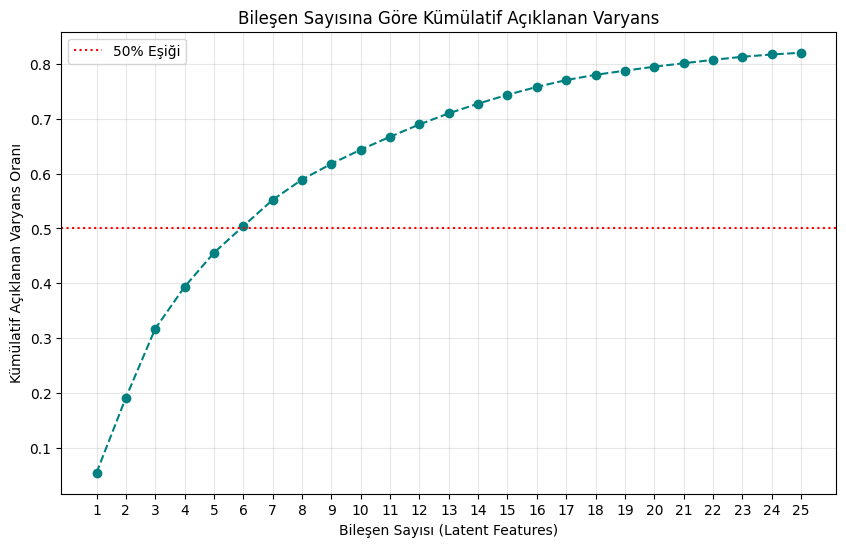

25 bileşen ile verideki toplam varyansın %82.05 kadarı temsil ediliyor.


In [42]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Her bir bileşenin açıkladığı varyans oranını alalım
explained_variance = svd.explained_variance_ratio_

# 2. Kümülatif (birikimli) toplamı hesaplayalım
# Bu bize "ilk n bileşen toplamda bilginin yüzde kaçını tutuyor?" sorusunun cevabını veriyor
cumulative_variance = np.cumsum(explained_variance)

# 3. Grafik Çizimi
plt.figure(figsize=(10, 6))
plt.plot(range(1, 26), cumulative_variance, marker='o', linestyle='--', color='teal')

plt.title('Bileşen Sayısına Göre Kümülatif Açıklanan Varyans')
plt.xlabel('Bileşen Sayısı (Latent Features)')
plt.ylabel('Kümülatif Açıklanan Varyans Oranı')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 26))

plt.axhline(y=0.5, color='r', linestyle=':', label='50% Eşiği')
plt.legend()

plt.show()

# Toplam sonucu da yazdıralım
print(f"25 bileşen ile verideki toplam varyansın %{cumulative_variance[-1]*100:.2f} kadarı temsil ediliyor.")

Sadece ilk 25 bileşenle (başlangıçta yaklaşık 1700 olan) varyansın **%80'inden fazlasını** açıklayabildiğimizi görüyoruz, bu da çalışma amaçlarımız için yeterlidir.

👉 **Bu matrisin 25 bileşenini, filmlerin başlıklarına göre indekslenmiş yeni bir `latent_df` veri çerçevesine kaydedin.**

In [43]:
import pandas as pd

# 1. TruncatedSVD sonuçlarını (latent_matrix) bir DataFrame'e dönüştürelim
# İndeks olarak merged_df içindeki film başlıklarını (title) kullanıyoruz
latent_df = pd.DataFrame(latent_matrix, index=merged_df['title'])

# 2. Sütun isimlerini daha anlaşılır hale getirelim
# Latent_1, Latent_2 ... Latent_25 şeklinde isimlendirebiliriz
latent_df.columns = [f'Latent_{i+1}' for i in range(latent_df.shape[1])]

# 3. Sonucu kontrol edin
print(f"Latent DataFrame Boyutu: {latent_df.shape}")
latent_df.head()


Latent DataFrame Boyutu: (9724, 25)


,Latent_1,Latent_2,Latent_3,Latent_4,Latent_5,Latent_6,Latent_7,Latent_8,Latent_9,Latent_10,...,Latent_16,Latent_17,Latent_18,Latent_19,Latent_20,Latent_21,Latent_22,Latent_23,Latent_24,Latent_25
title,,,,,,,,,,,,,,,,,,,,,
Toy Story (1995),0.906946,0.969612,-0.642147,-0.496715,0.916093,0.982556,-0.730280,0.424489,0.068656,-0.213954,...,-0.130425,-0.211222,-0.014320,0.018591,0.003824,-0.039222,-0.074825,-0.004178,-0.037505,-0.001531
Jumanji (1995),0.412993,0.161520,-0.589471,-0.697434,1.038275,1.271058,-0.499947,0.377932,0.385751,0.340000,...,0.576782,-0.207436,0.020372,-0.017218,0.009734,-0.015241,-0.090534,-0.019570,-0.014867,0.000143
Grumpier Old Men (1995),0.765626,0.916211,0.122049,0.018001,-0.281955,0.207152,0.653873,0.063522,-0.031535,0.004238,...,-0.012512,-0.061190,0.001084,0.004300,-0.004157,0.005158,0.004476,0.005921,-0.001285,-0.005931
Waiting to Exhale (1995),1.413731,0.503254,0.641974,-0.225147,-0.260513,0.088929,0.437675,-0.028976,-0.023642,-0.003315,...,-0.019017,-0.078481,-0.030055,0.008139,-0.012147,-0.000817,0.006722,0.005786,0.002877,-0.005983
Father of the Bride Part II (1995),0.523686,0.780103,-0.056799,0.187916,-0.098330,-0.146743,-0.155329,-0.108346,-0.106465,0.029363,...,-0.026957,-0.006599,-0.004276,0.005794,-0.004677,0.011976,0.004103,0.012745,-0.014701,-0.040927


### 🧪 Kodunu Test Et

In [44]:
from nbresult import ChallengeResult

result =  ChallengeResult(
    'metadata',
    counter_shape=count_df.shape,
    latent_shape=latent_df.shape
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S17D3-S-data-movie-recommendation/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 3 items

test_metadata.py::TestMetadata::test_counter_columns PASSED              [ 33%]
test_metadata.py::TestMetadata::test_counter_rows PASSED                 [ 66%]
test_metadata.py::TestMetadata::test_features_number PASSED              [100%]

============================== 3 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/metadata.pickle

git commit -m 'Completed metadata step'

git push origin master



## Kullanıcı Derecelendirmelerinden Latent Matris Oluşturma

Meta veriler dışında, bir başka değerli bilgi kaynağımız daha var: **kullanıcı derecelendirmeleri**. 

Bir öneri sistemi, kullanıcı derecelendirmelerine dayanarak benzer bir film önerebilir (öğeden öğeye işbirliğine dayalı filtreleme).

👉 **Aşağıdaki veri setini, filmleri satırlara, `userId`'leri sütunlara yerleştirecek şekilde hazırlıyoruz.**

In [45]:
# Merge
ratings1 = pd.merge(movies[['movieId']], ratings, on="movieId", how="right")
# Pivot
ratings2 = ratings1.pivot(index = 'movieId', columns ='userId', values = 'rating').fillna(0)
display(ratings2.head())
ratings2.shape

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,4.0,0.0,4.5,0.0,0.0,0.0,...,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


(9724, 610)

Kullanıcıların puanlarını 9724 uzunluğunda vektörler olarak içeren bir veri kümesi oluşturduk.

👉**Yine, ilk 200 bileşeni saklamak için `ratings2` veri çerçevesine SVD uygulayacağız. Bu veri çerçevesine `latent_df_2` adını verin.**

In [46]:
from sklearn.decomposition import TruncatedSVD

# 1. TruncatedSVD nesnesini 200 bileşenle yapılandıralım
svd_user = TruncatedSVD(n_components=200, random_state=42)

# 2. ratings2 matrisine (User-Item Matrix) SVD uygulayalım
# Not: ratings2 zaten (filmler x kullanıcılar) yapısında olduğu için doğrudan fit_transform yapabiliriz
latent_matrix_2 = svd_user.fit_transform(ratings2)

# 3. latent_df_2 oluşturma (indeks olarak movieId'leri kullanıyoruz)
latent_df_2 = pd.DataFrame(latent_matrix_2, index=ratings2.index)

# Sütun isimlerini netleştirelim
latent_df_2.columns = [f'UserLatent_{i+1}' for i in range(latent_df_2.shape[1])]

print(f"Orijinal boyut (Filmler x Kullanıcılar): {ratings2.shape}")
print(f"İndirgenmiş boyut (Filmler x Gizli Bileşenler): {latent_df_2.shape}")
latent_df_2.head()

Orijinal boyut (Filmler x Kullanıcılar): (9724, 610)
İndirgenmiş boyut (Filmler x Gizli Bileşenler): (9724, 200)


,UserLatent_1,UserLatent_2,UserLatent_3,UserLatent_4,UserLatent_5,UserLatent_6,UserLatent_7,UserLatent_8,UserLatent_9,UserLatent_10,...,UserLatent_191,UserLatent_192,UserLatent_193,UserLatent_194,UserLatent_195,UserLatent_196,UserLatent_197,UserLatent_198,UserLatent_199,UserLatent_200
movieId,,,,,,,,,,,,,,,,,,,,,
1,37.649828,-6.380094,-14.994617,-0.286947,1.887147,-4.790050,-8.807629,-2.198637,-1.153304,-1.387562,...,1.509259,2.571558,1.079884,-1.489578,1.162201,-0.635675,0.914679,-0.016347,0.754628,-2.552653
2,20.596193,-0.477880,-10.865916,8.635795,3.072411,0.517149,-4.359215,-3.821408,3.394117,-0.236474,...,0.741599,-0.827772,0.439950,1.747872,0.308577,1.728965,0.808715,0.755086,-1.051243,1.672944
3,8.504182,-5.714924,-3.441693,6.382810,-0.024162,0.783432,1.423027,-0.542292,-3.270655,-1.897238,...,0.261826,-0.553680,-0.386709,0.085206,-0.116957,-0.844441,0.335339,-0.345159,1.245748,0.182475
4,0.465720,-0.828101,-0.954583,0.239080,0.735695,0.877414,-0.214720,-0.527368,-0.079467,-0.015616,...,-0.063262,0.347930,0.193935,0.054893,-0.171441,0.137140,-0.180395,0.195418,0.011186,0.740383
5,6.071045,-2.673536,-4.698195,4.415807,3.714221,1.673627,-1.297653,-1.308023,-1.325734,-1.229592,...,-0.141982,-0.253920,-0.206540,0.256493,0.425539,-0.030499,1.036760,-1.443857,0.583250,0.836855


**👉 Film Adına Göre Yeniden Dizin Oluştur.**

In [47]:
# 1. ratings2'deki movieId indeksini title (başlık) ile eşleştirmek için 
# movies tablosundan bir eşleşme sözlüğü (mapping) oluşturalım
movie_titles = movies.set_index('movieId')['title']

# 2. latent_df_2'nin indeksini movieId'den film başlığına (title) çevirelim
latent_df_2.index = latent_df_2.index.map(movie_titles)

print("Kullanıcı Tabanlı Latent Matris (İlk 5 Satır):")
display(latent_df_2.head())

Kullanıcı Tabanlı Latent Matris (İlk 5 Satır):


,UserLatent_1,UserLatent_2,UserLatent_3,UserLatent_4,UserLatent_5,UserLatent_6,UserLatent_7,UserLatent_8,UserLatent_9,UserLatent_10,...,UserLatent_191,UserLatent_192,UserLatent_193,UserLatent_194,UserLatent_195,UserLatent_196,UserLatent_197,UserLatent_198,UserLatent_199,UserLatent_200
movieId,,,,,,,,,,,,,,,,,,,,,
Toy Story (1995),37.649828,-6.380094,-14.994617,-0.286947,1.887147,-4.790050,-8.807629,-2.198637,-1.153304,-1.387562,...,1.509259,2.571558,1.079884,-1.489578,1.162201,-0.635675,0.914679,-0.016347,0.754628,-2.552653
Jumanji (1995),20.596193,-0.477880,-10.865916,8.635795,3.072411,0.517149,-4.359215,-3.821408,3.394117,-0.236474,...,0.741599,-0.827772,0.439950,1.747872,0.308577,1.728965,0.808715,0.755086,-1.051243,1.672944
Grumpier Old Men (1995),8.504182,-5.714924,-3.441693,6.382810,-0.024162,0.783432,1.423027,-0.542292,-3.270655,-1.897238,...,0.261826,-0.553680,-0.386709,0.085206,-0.116957,-0.844441,0.335339,-0.345159,1.245748,0.182475
Waiting to Exhale (1995),0.465720,-0.828101,-0.954583,0.239080,0.735695,0.877414,-0.214720,-0.527368,-0.079467,-0.015616,...,-0.063262,0.347930,0.193935,0.054893,-0.171441,0.137140,-0.180395,0.195418,0.011186,0.740383
Father of the Bride Part II (1995),6.071045,-2.673536,-4.698195,4.415807,3.714221,1.673627,-1.297653,-1.308023,-1.325734,-1.229592,...,-0.141982,-0.253920,-0.206540,0.256493,0.425539,-0.030499,1.036760,-1.443857,0.583250,0.836855


In [48]:
latent_df_2.shape

(9724, 200)

### 🧪 Kodunu Test Et

In [49]:
from nbresult import ChallengeResult

result = ChallengeResult('ratings', latent_shape=latent_df_2.shape)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S17D3-S-data-movie-recommendation/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_ratings.py::TestRatings::test_latent_shape PASSED                   [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/ratings.pickle

git commit -m 'Completed ratings step'

git push origin master



## İçerik ve İşbirlikçi (Collaborative) Matrislerde Kosinüs Benzerliği Uygulama

Sonraki adımda, oluşturduğumuz filtreleme yöntemlerine dayanarak **“Toy Story” filmine en çok benzeyen ilk $N$ filmi** bulmak için bir benzerlik ölçüsü kullanacağız. Kullanabileceğimiz benzerlik ölçülerinden biri **Kosinüs Benzerliği**dir. Scikit-learn’de bu işlem için [`cosine_similarity`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html) fonksiyonu bulunur.

👉 **Örnek bir film (“Toy Story”) için hem içerik (metadata) hem de işbirlikçi (puanlar) latent matrislerine karşı kosinüs benzerliğini hesaplayın.**

In [50]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Hedef filmimizi seçelim
target_movie = "Toy Story (1995)"

# --- İÇERİK TABANLI BENZERLİK (metadata / latent_df) ---
# Toy Story'nin içerik vektörünü alalım
v_content = latent_df.loc[[target_movie]] 
# Tüm matris ile Toy Story arasındaki benzerliği hesaplayalım
sim_content = cosine_similarity(latent_df, v_content)

# --- İŞBİRLİKÇİ BENZERLİK (ratings / latent_df_2) ---
# Toy Story'nin kullanıcı puanı vektörünü alalım
v_collab = latent_df_2.loc[[target_movie]]
# Tüm matris ile Toy Story arasındaki benzerliği hesaplayalım
sim_collab = cosine_similarity(latent_df_2, v_collab)

Ayrıca, içerik ve işbirliğine dayalı filtrelemenin benzerlik ortalamasını alan bir hibrit filtre de oluşturabiliriz. 

`hybrid_similarity = (content_similarity + collaborative_similarity) / 2`

__İçerik ve işbirliğine dayalı filtrelemenin benzerlik ortalamasını hesaplayın.__

In [54]:
# 1. Benzerlik skorlarını .flatten() ile tek boyutlu hale getirelim
sim_content_1d = sim_content.flatten()
sim_collab_1d = sim_collab.flatten()
hybrid_similarity = (sim_content_1d + sim_collab_1d) / 2

__Toy Story ile nihai benzerlikleri içeren bir dataframe oluşturun.__

In [55]:
# 2. DataFrame oluştururken bu düzleştirilmiş (1D) dizileri kullanalım
recommendation_df = pd.DataFrame({
    'content_similarity': sim_content_1d,
    'collaborative_similarity': sim_collab_1d,
    'hybrid_similarity': hybrid_similarity
}, index=latent_df.index)

# 3. Kendisini çıkarıp ve sıralayalım
recommendation_df = recommendation_df.drop(target_movie)
display(recommendation_df.sort_values("hybrid_similarity", ascending=False).head(10))

,content_similarity,collaborative_similarity,hybrid_similarity
title,,,
Toy Story 2 (1999),0.946801,0.642173,0.794487
"Monsters, Inc. (2001)",0.999663,0.553818,0.776741
Shrek (2001),0.912430,0.587650,0.750040
"Bug's Life, A (1998)",0.896113,0.527741,0.711927
Finding Nemo (2003),0.895501,0.524941,0.710221
Antz (1998),0.999663,0.393385,0.696524
Toy Story 3 (2010),0.913228,0.477271,0.695249
Aladdin (1992),0.795150,0.577269,0.686210
Ice Age (2002),0.895876,0.433960,0.664918


__Data Frame'inizi işbirliğine dayalı benzerlik açısından en benzer olanlara göre sıralayın.__

In [56]:
# İşbirliğine dayalı (collaborative_similarity) sütununa göre büyükten küçüğe sırala
collaborative_top_10 = recommendation_df.sort_values(by='collaborative_similarity', ascending=False).head(10)

print("Toy Story ile İşbirliğine Dayalı (Kullanıcı Alışkanlıkları) En Benzer 10 Film:")
display(collaborative_top_10)

Toy Story ile İşbirliğine Dayalı (Kullanıcı Alışkanlıkları) En Benzer 10 Film:


,content_similarity,collaborative_similarity,hybrid_similarity
title,,,
Toy Story 2 (1999),0.946801,0.642173,0.794487
Independence Day (a.k.a. ID4) (1996),0.198082,0.625355,0.411718
Jurassic Park (1993),0.198981,0.611037,0.405009
Mission: Impossible (1996),0.222322,0.603415,0.412868
Star Wars: Episode IV - A New Hope (1977),0.094482,0.591968,0.343225
Shrek (2001),0.912430,0.587650,0.750040
"Lion King, The (1994)",0.526536,0.583535,0.555035
Star Wars: Episode VI - Return of the Jedi (1983),0.190899,0.579852,0.385376
Forrest Gump (1994),0.220679,0.579440,0.400060


Elbette Toy Story'yi en benzer film olarak görmelisiniz (her sütun için benzerlik 1).

__Content ve hybrid türe göre sıralama yapabilir ve hangisinin en iyi öneriyi verdiğini görebilirsiniz.__

In [57]:
# 1. İçerik Tabanlı (Tür ve Etiket benzerliği)
content_top = recommendation_df.sort_values('content_similarity', ascending=False).head(5)

# 2. İşbirlikçi (Kullanıcı davranışı / Puanlama benzerliği)
collab_top = recommendation_df.sort_values('collaborative_similarity', ascending=False).head(5)

# 3. Hibrit (Her ikisinin ortalaması)
hybrid_top = recommendation_df.sort_values('hybrid_similarity', ascending=False).head(5)

print("--- CONTENT BASED ---")
print(content_top.index.tolist())

print("\n--- COLLABORATIVE ---")
print(collab_top.index.tolist())

print("\n--- HYBRID ---")
print(hybrid_top.index.tolist())

--- CONTENT BASED ---
['Adventures of Rocky and Bullwinkle, The (2000)', 'Wild, The (2006)', "Emperor's New Groove, The (2000)", 'Shrek the Third (2007)', 'Tale of Despereaux, The (2008)']

--- COLLABORATIVE ---
['Toy Story 2 (1999)', 'Independence Day (a.k.a. ID4) (1996)', 'Jurassic Park (1993)', 'Mission: Impossible (1996)', 'Star Wars: Episode IV - A New Hope (1977)']

--- HYBRID ---
['Toy Story 2 (1999)', 'Monsters, Inc. (2001)', 'Shrek (2001)', "Bug's Life, A (1998)", 'Finding Nemo (2003)']


**❓ Gerçekçi bir film öneri sistemi oluşturmak için hangi benzerlik daha iyidir?  Bunu `best_similarity` değişkenine atayın.**

In [58]:
a = 'content'
b = 'collaborative'
c = 'hybrid'
best_similarity = c # fill in with the right answer

### 🧪 Kodunu Test Et

In [59]:
from nbresult import ChallengeResult

result = ChallengeResult('recommender', best_similarity=best_similarity)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S17D3-S-data-movie-recommendation/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_recommender.py::TestRecommender::test_best_similarity PASSED        [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/recommender.pickle

git commit -m 'Completed recommender step'

git push origin master



## 🏁 Aferin!

Kodunuzu GitHub'da commit ve push edebilirsiniz.